1 model review

2 hardware benchmark

3 Flash attention design and parallelization

4 GEMM design

5 Total benchmark

Constitution:

1 Prefill | Decode for every section

In [1]:
from helper import plot, plot_roofline

## LlaMA 8B

Prefill Intensity: 384.47 FLOPs/byte

Decode Intensity: 19.46 FLOPs/byte

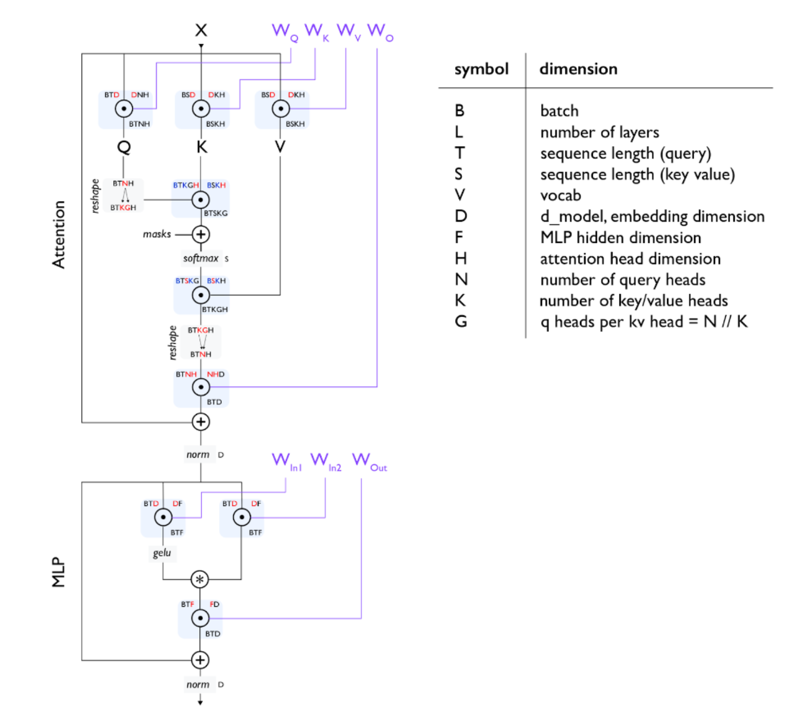

In [2]:
img = "img/LLM_tuning.png"
plot("img/LLM_tuning.png", 800)

B = 16 # Batch size
L = 32 # Layers
T = 2048 # Q length
S = 2048 # K length
D = 4096 # dimension
F = 14336 # FFN inter dim
N = 32 # Q head
K = 8 # KV head
H = 128 # d_head
G = N / K # Q heads / KV head
d_kv = 1024 # d_kv


# Attention
Q_shape = B * T * K * G * H # 16 x 2048 x 8 x 4 x 128
K_shape = B * S * K * H # 16 x 2048 x 8 x 128
V_shape = B * S * K * H # 16 x 2048 x 8 x 128



## Hardware


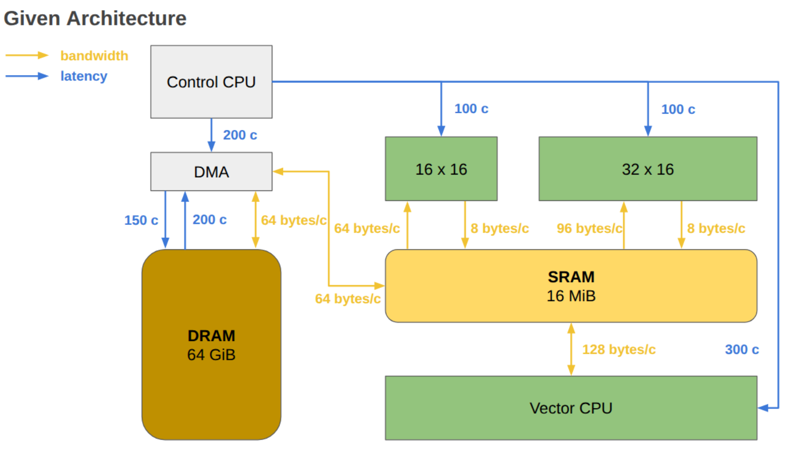

In [3]:
plot("img/architecture.png", 800)

**The 8 B/c output port is the bottleneck.**

**sa2 has no advantage on K = 128, and a 2× advantage on k = 256.**

**K >= 128 Memory bound, <= computation bound**

when K = 128, sa1 complete same macs in the same cycle (128)

    K=32
    sa1 macs: 8192, cycle:64
    sa2 macs: 16384, cycle:128
    K=64
    sa1 macs: 16384, cycle:64
    sa2 macs: 32768, cycle:128
    K=128
    sa1 macs: 32768, cycle:128
    sa2 macs: 65536, cycle:128
    K=256
    sa1 macs: 65536, cycle:256
    sa2 macs: 131072, cycle:256

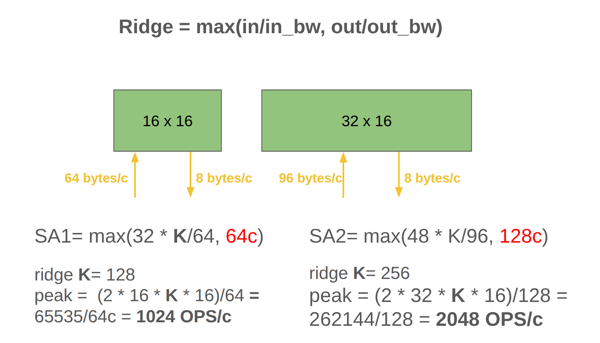

In [4]:
plot("img/SA_ridge.png", 600)

### Roofline analysis

Given the chip architecture and model hyperparameter, we plot the roofline:

chip ridge = 48.0


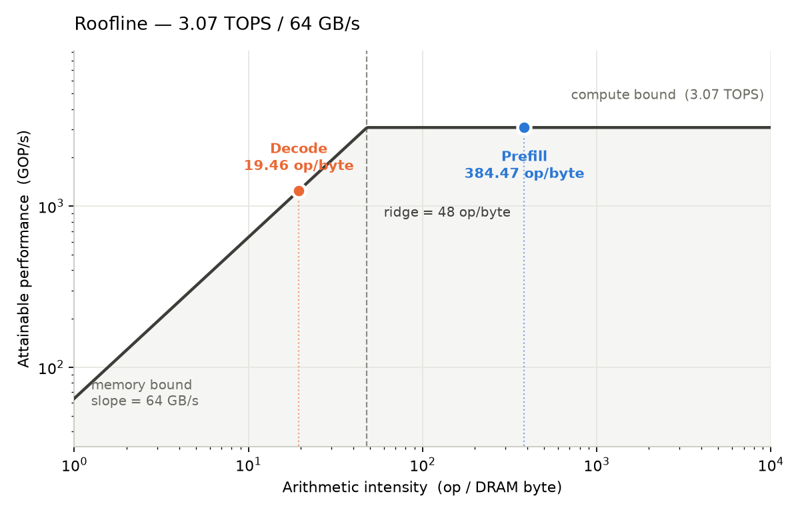

In [5]:
ridge_K_SA1 = 128
ridge_K_SA2 = 256
ops_SA1 = (2 * 16 * ridge_K_SA1 * 16) / 64
ops_SA2 = (2 * 32 * ridge_K_SA2 * 16) / 128
peak_ops = ops_SA1 + ops_SA2

peak_mem = 64 # DRAM -> SRAM

print(f"chip ridge = {peak_ops / peak_mem}")

plot(f"img/roofline.png", 800)

## Flash Attention - V2


    two operations uses SA unit
    1 S = Q K^T
    2 P V

### Prefill

    Inputs: Q16, K16, V16 in DRAM; block sizes Br, Bc

    CPU: allocate SRAM buffers

    DMA: DRAM → SRAM: load K16 and V16; wait
    VCPU: quantize K and V to INT8; pack transposed V; wait

    for each query block Qi:

        DMA: DRAM → SRAM: load Qi; wait

        VCPU:
            Quantize Qi → Q8, with scale sQ
            Initialize FP32 state: U = 0, l = 0, m = -inf
        wait

        for each Kj visible:

            S = Dot8(Q8, K8j, sQ, sK)
            Returns scaled QK^T in SRAM

            VCPU:
                S = S / sqrt(d)
                Apply causal mask to S

                new_m = max(m, rowmax(S))
                alpha = exp(m - new_m)
                P = exp(S - new_m)

                block_sum = rowsum(P)
                Quantize P → P8, with row scales sP
            wait

            C = Dot8(P8, packed_V8j_transpose, sP, sV)
            Returns scaled PV contribution in SRAM

            VCPU:
                U = alpha[:, None] * U + C
                l = alpha * l + block_sum
            wait

            CPU: swap m and new_m buffer pointers

        VCPU:
            O = U / l[:, None]
            Encode O using the specified INT16 output scale
        wait

        DMA: SRAM → DRAM: store this output block; wait

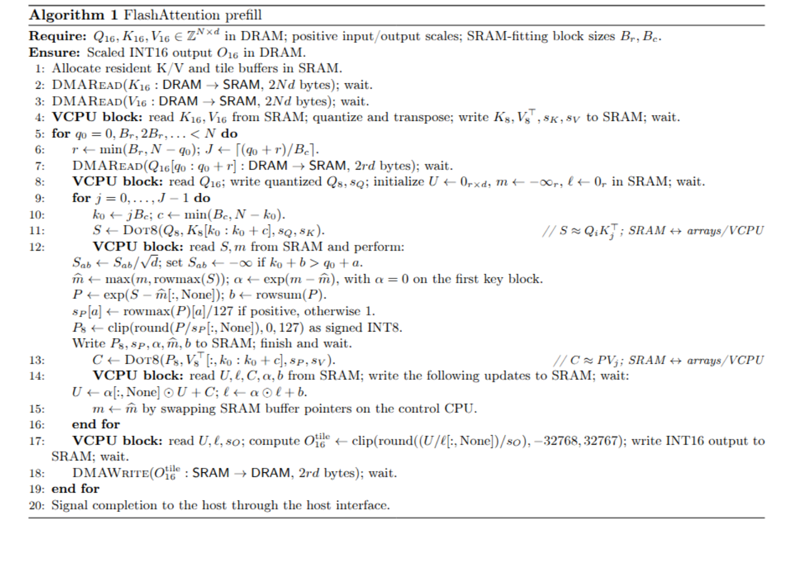

In [6]:
plot("img/fa2_prefill.png", 800)

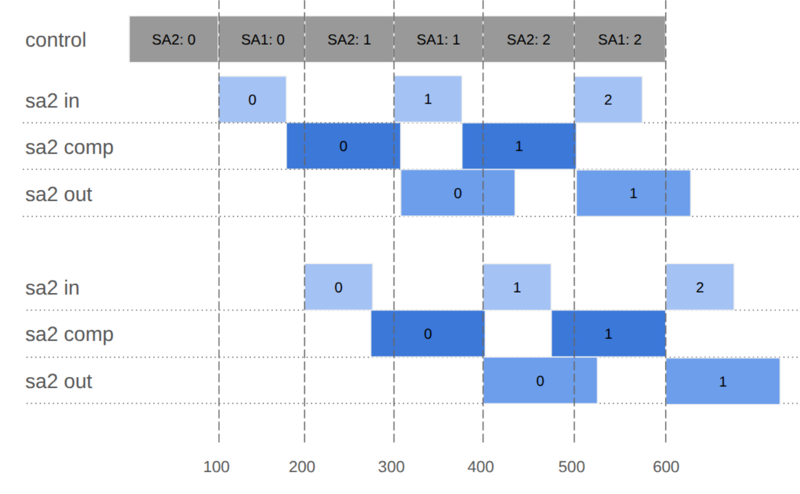

In [10]:
plot("img/schedule.png", 800)

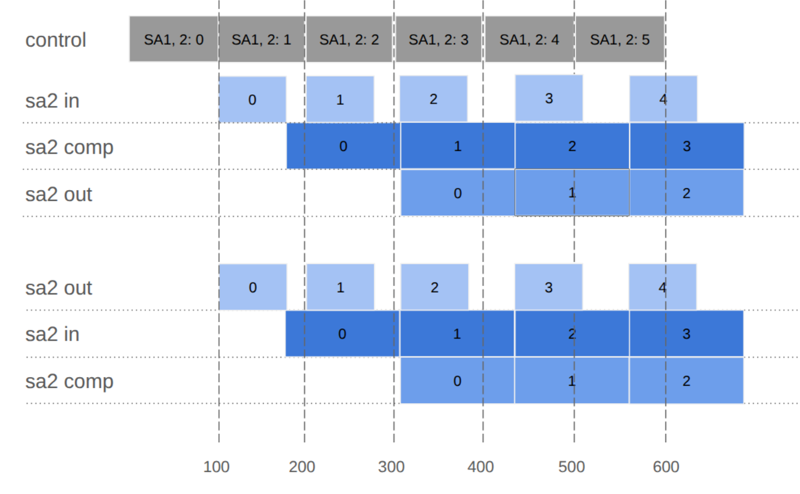

In [9]:
plot("img/schedule_seq.png", 800)